# STA 141B Final Project

## Environment Setup

In [ ]:
# Import required package - Usual packages
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.patches as patches
import seaborn as sns
from sklearn.decomposition import PCA
import re
from IPython.display import display

# Unusual packages Check and install
#packages = ['pywaffle', 'tqdm']
!pip install pywaffle
!pip install missingno

from pywaffle import Waffle
import missingno as msno
import tqdm
import pip
import sys

"""
if 'gdown' in sys.modules:
  __import__('gdown')
else:
  pip.main(['install', 'gdown'])
  import gdown
"""

# Settings
warnings.filterwarnings('ignore')
sns.set_style('white')
plt.rcParams['figure.dpi'] = 500
mpl.rcParams['axes.spines.left'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.bottom'] = False
#sns.set(rc={'axes.facecolor': '#FBFBFB', 'figure.facecolor': '#FBFBFB'})
plt.rcParams["font.family"] = "serif"
pd.set_option('display.max_columns', None)

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Text(0.5, 0.98, 'Color Palette')

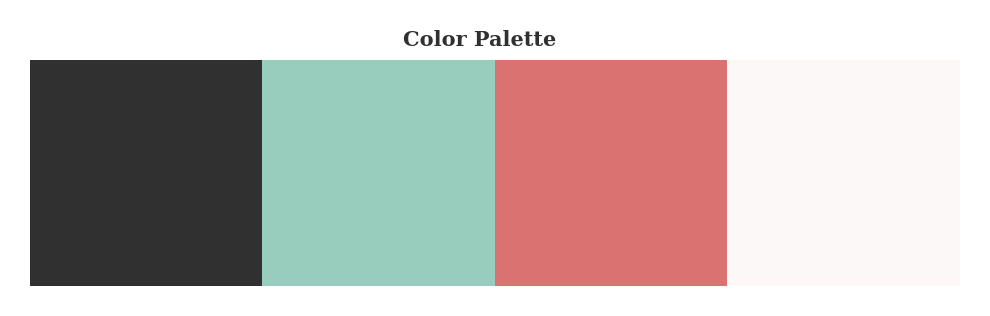

In [ ]:
# 不会放入最终
colors = ['#303030' ,'#98CDBE','#D97271','#FDF8F8']
sns.palplot(colors)
plt.suptitle('Color Palette', fontweight='heavy', ha='center', fontsize=5, color=colors[0])

## Project Workflow
### Jupyter Notebook Data Download and environment Setup

In [ ]:
import platform
mysystem = platform.system()
file_download_link = 'https://drive.google.com/uc?id=1mLS7-mhwMhkcBdt0NdBOHK3iz-EXzBeS'
# Check for windows
if mysystem != 'Windows':
    !wget -O cancer_data.zip --no-check-certificate "$file_download_link"
    !unzip cancer_data.zip

print('Please download the data using the following link:', file_download_link)

--2022-11-22 23:10:36--  https://drive.google.com/uc?id=1mLS7-mhwMhkcBdt0NdBOHK3iz-EXzBeS
Resolving drive.google.com (drive.google.com)... 142.251.8.113, 142.251.8.101, 142.251.8.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.8.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-10-4k-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/2o2n3m1ro045s4apphtv0qtvmdiabl0r/1669158600000/02492766363230714327/*/1mLS7-mhwMhkcBdt0NdBOHK3iz-EXzBeS?uuid=27b317f3-016c-4c9d-85f9-d0630928335f [following]
--2022-11-22 23:10:38--  https://doc-10-4k-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/2o2n3m1ro045s4apphtv0qtvmdiabl0r/1669158600000/02492766363230714327/*/1mLS7-mhwMhkcBdt0NdBOHK3iz-EXzBeS?uuid=27b317f3-016c-4c9d-85f9-d0630928335f
Resolving doc-10-4k-docs.googleusercontent.com (doc-10-4k-docs.googleusercontent.com)... 142.250.157.132, 2404:6800:4008:c13::84
Connecting to doc-10-4k

### Initial Data Exploration

### Data Cleaning

In [ ]:
# Read data
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Text(0.5, 1.0, 'Missing / Null Values Graph')

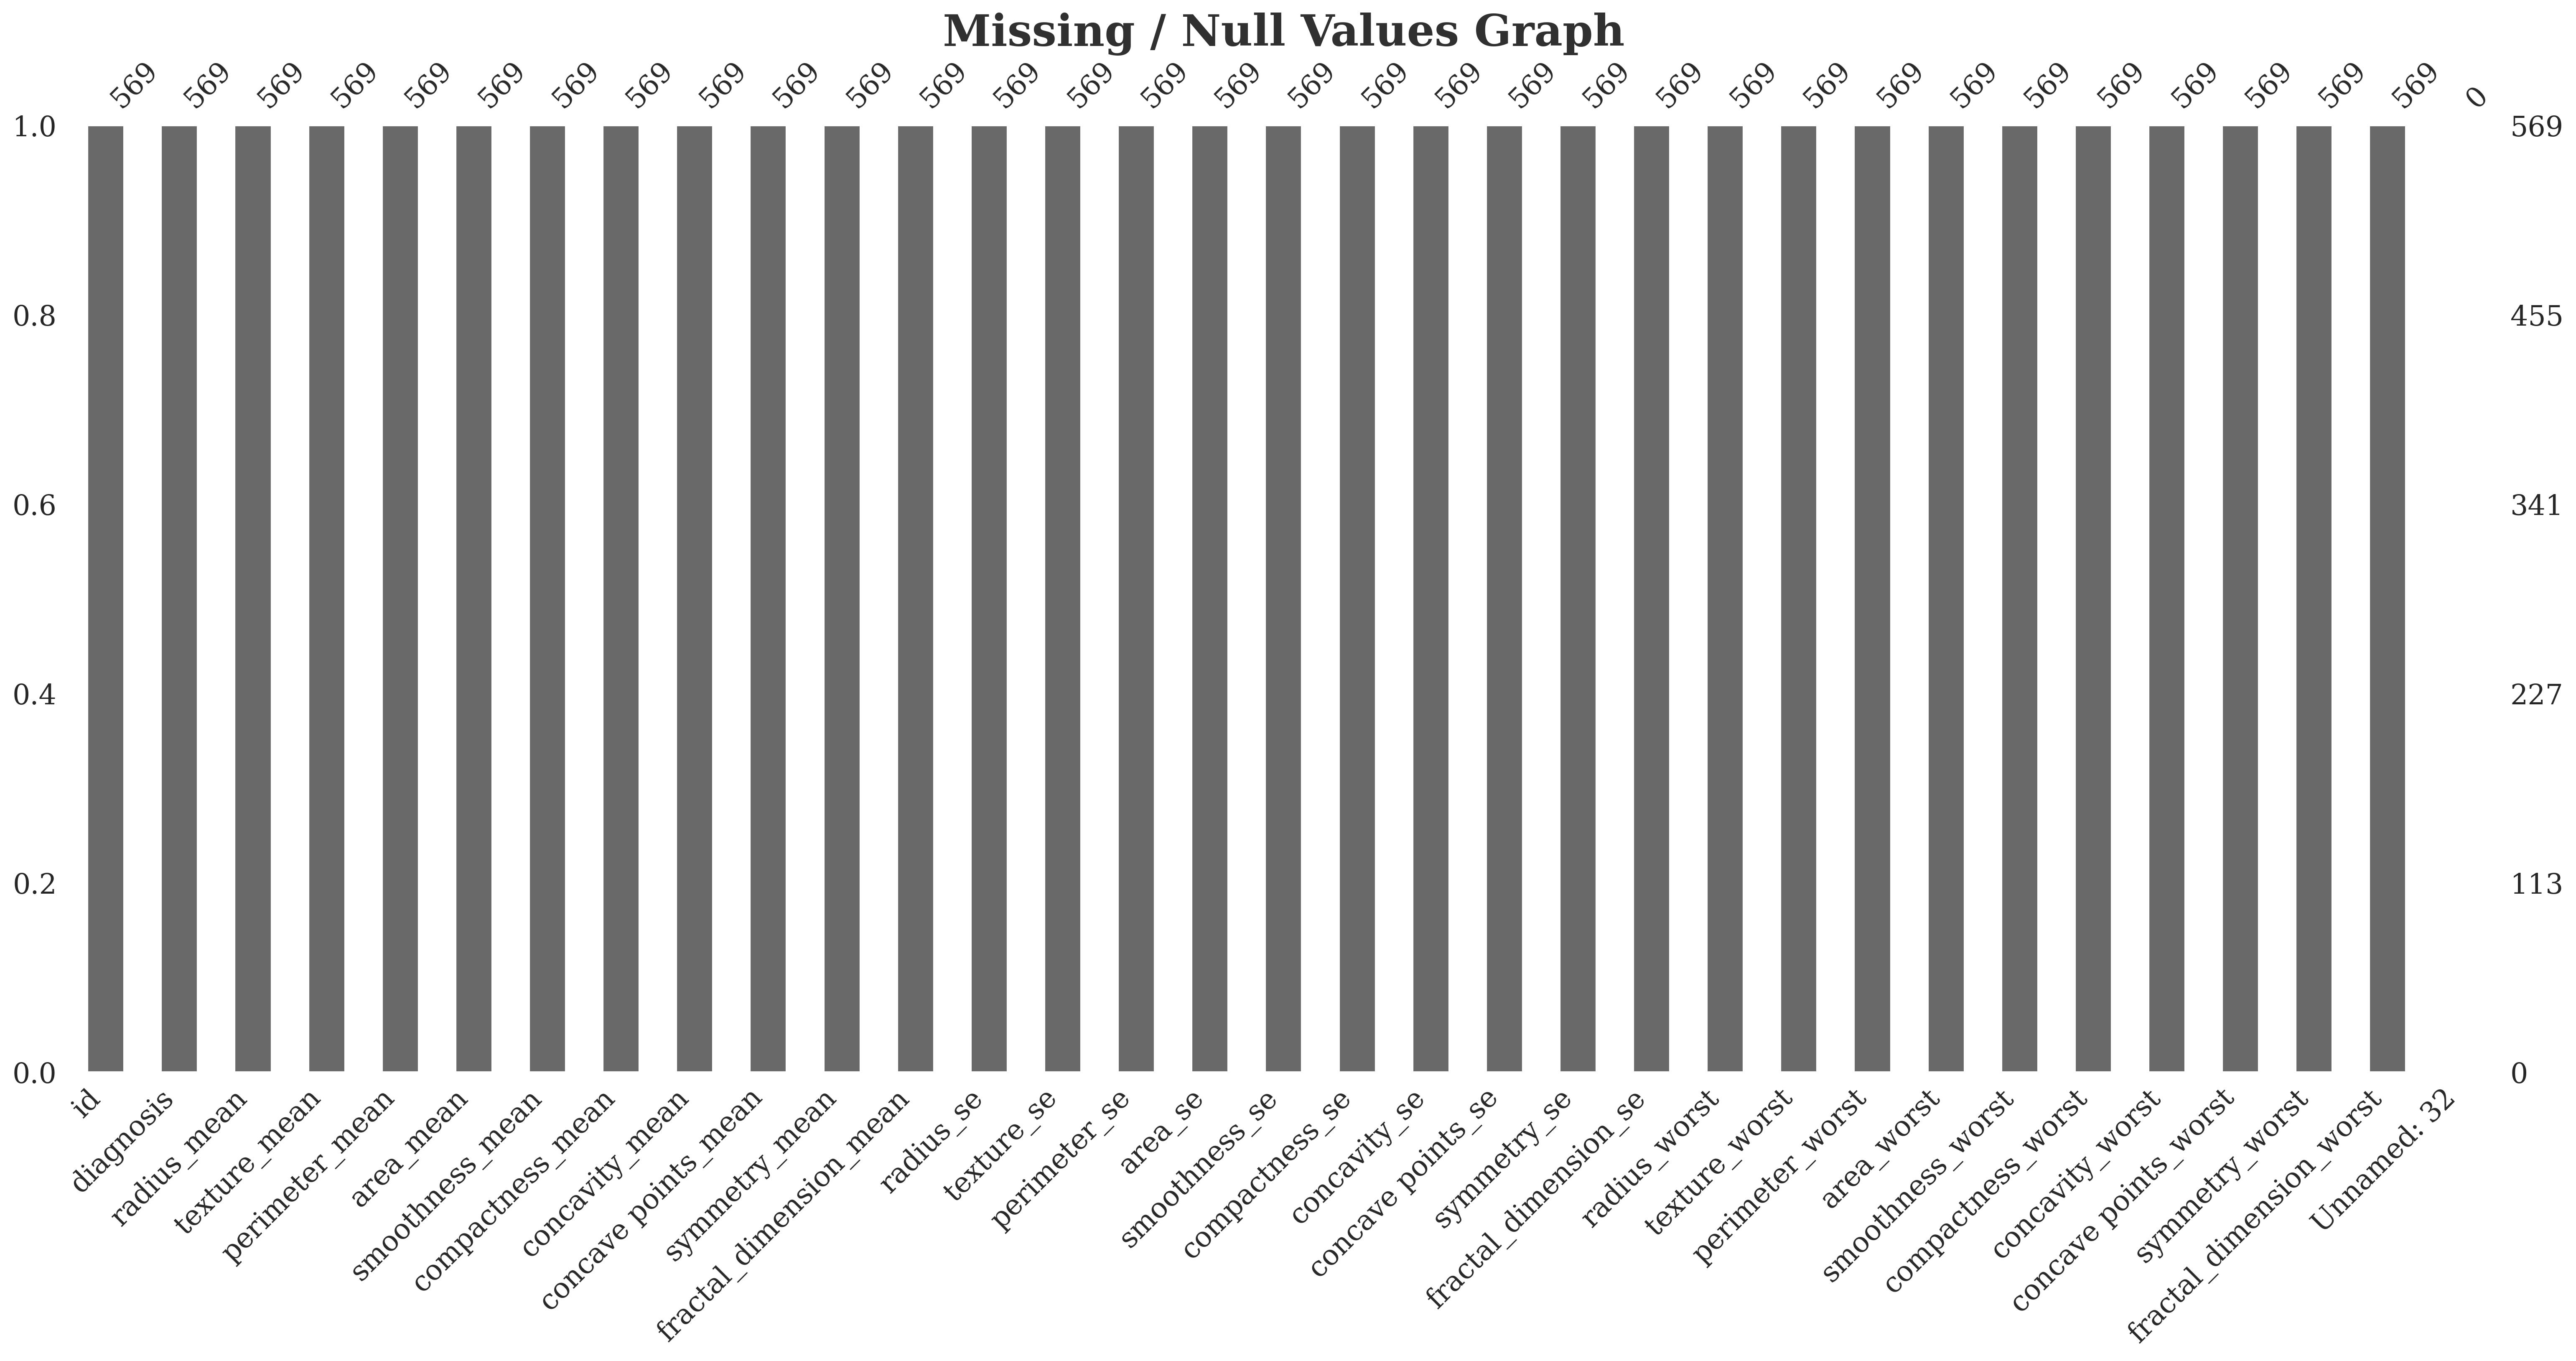

In [ ]:
# Check null variables
#df.isnull().sum()

msno.bar(df)
plt.title('Missing / Null Values Graph', fontweight='heavy', ha='center', fontsize=25, color=colors[0])

We can see that the column `Unnamed: 32` has 569 missing values. Therefore we will remove this column in our dataset.

In [ ]:
# Set new dataframe
df = df.drop(df.columns[-1], axis=1)

### Delete an unnecessary column: `id`

In [ ]:
# Final cleaned dataset
df = df.drop(df.columns[0], axis=1)

In [ ]:
# Check columns
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
# Description of dataset
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## EDA

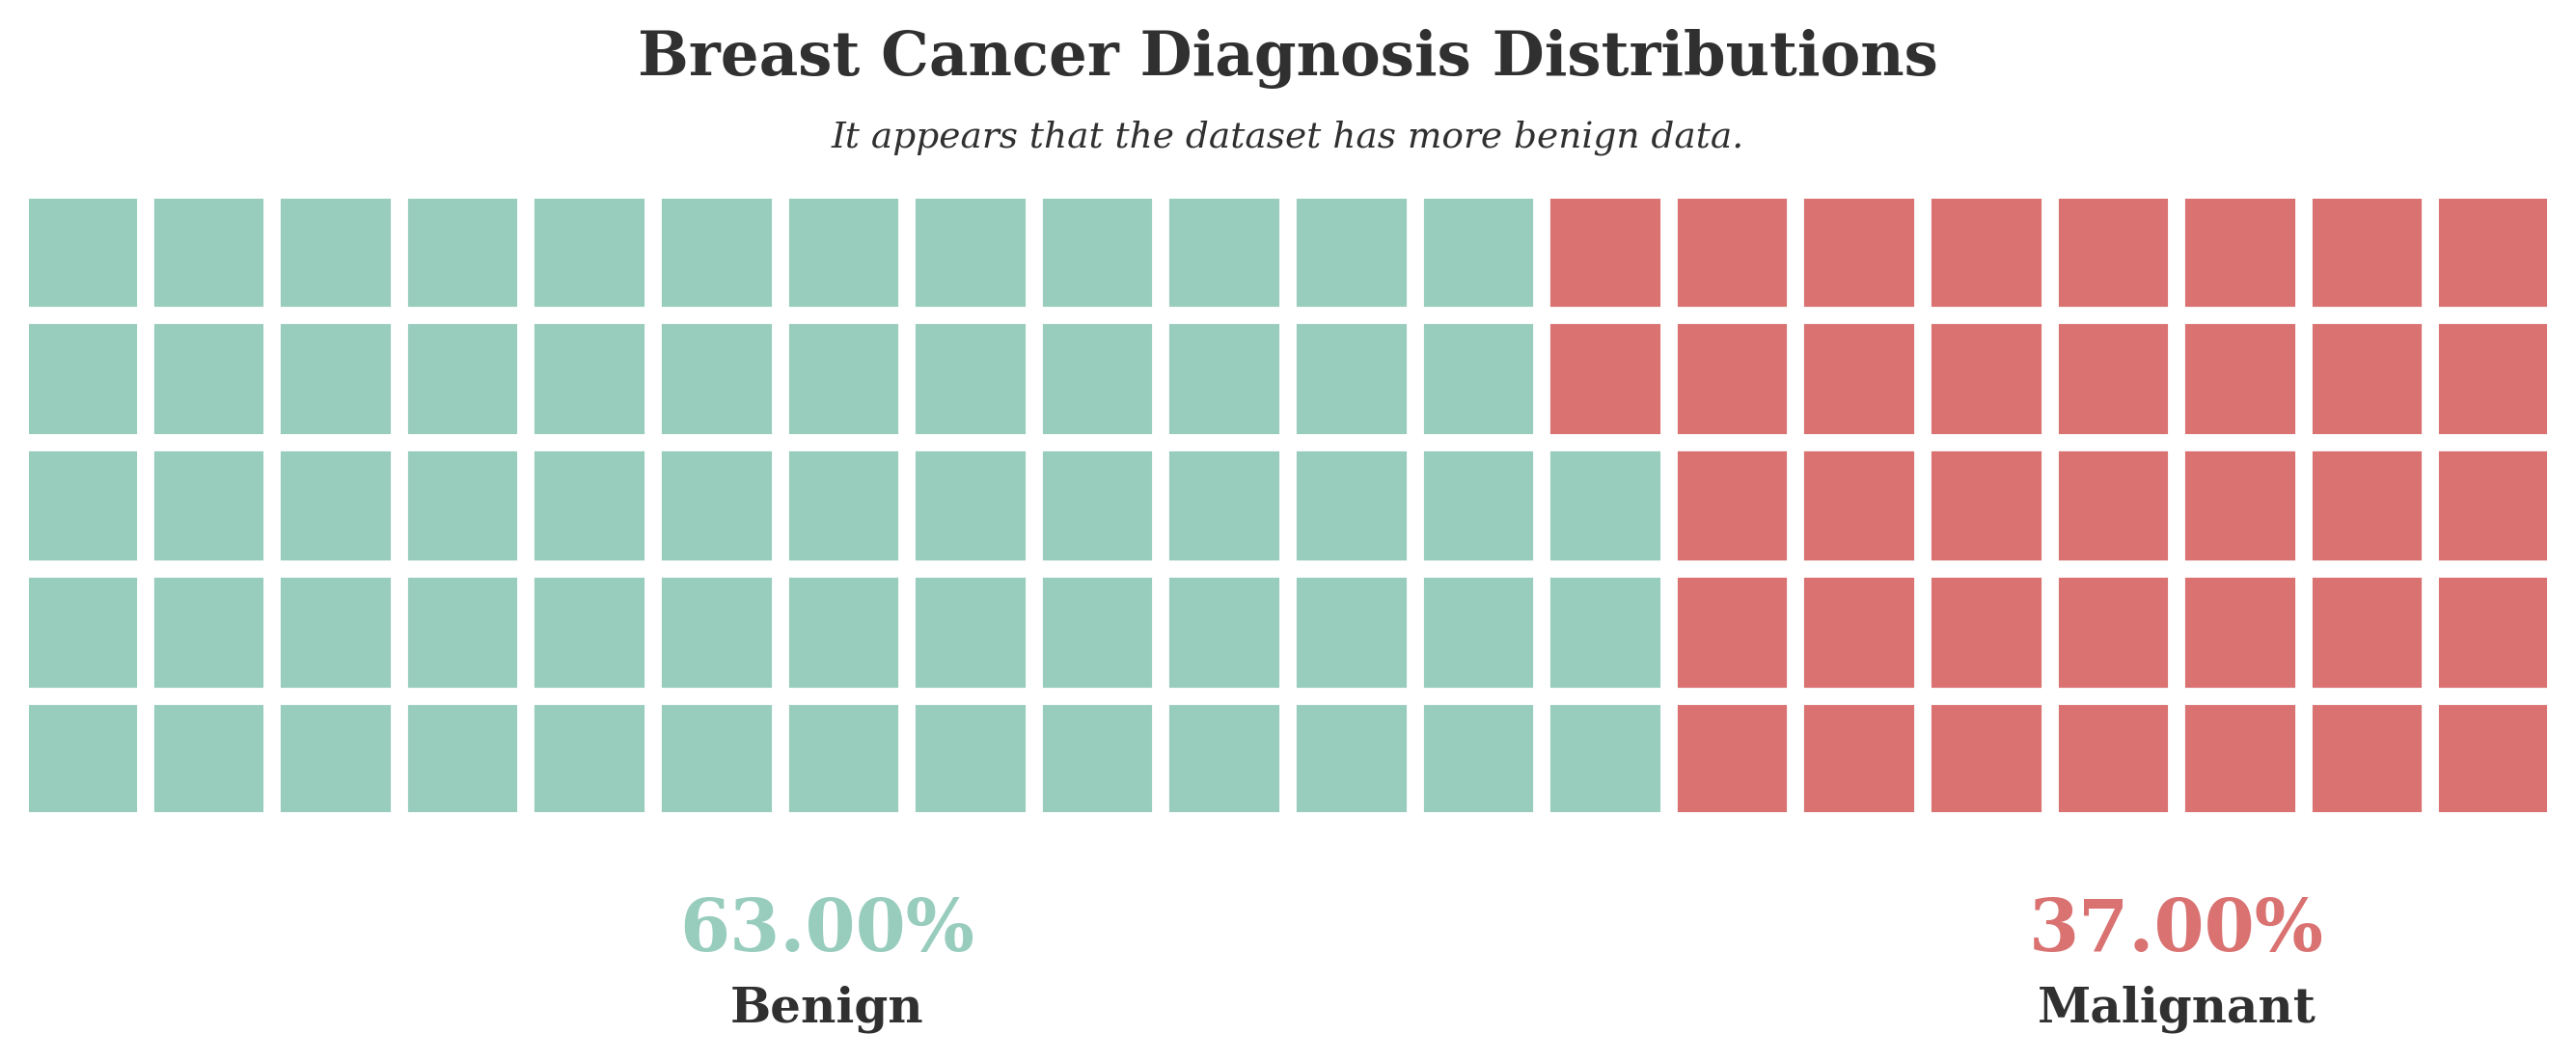

In [ ]:
# Plot the Waffle plot of diagnosis distribution of the dataset
target = df['diagnosis']
targetDist = round(target.value_counts(normalize = True),2)*100
labels = ['Benign', 'Malignant']

# Main Figure
fig = plt.figure(FigureClass=Waffle, rows=5, colors=colors[1:3], values=targetDist, figsize=(9, 5))
# Title and subtitle
plt.suptitle('Breast Cancer Diagnosis Distributions', fontweight='heavy', y=0.83, ha='center', fontsize=15, color=colors[0])
plt.title('It appears that the dataset has more benign data.\n',
          style='italic', fontsize=9, loc='center', y=0.98, ha='center',  color=colors[0])

# Legends
plt.text(1.3, -0.25, '{0:.2f}%'.format(targetDist[0]), color=colors[1], fontsize=18, ha='center', weight='bold', va='bottom')
plt.text(1.3, -0.28, labels[0], color=colors[0], fontsize=12, ha='center', va='top', weight='bold')
plt.text(3.5, -0.25, '{0:.2f}%'.format(targetDist[1]), color=colors[2], fontsize=18, ha='center', weight='bold', va='bottom')
plt.text(3.5, -0.28, labels[1], color=colors[0], fontsize=12, ha='center', va='top', weight='bold')
plt.show()

Through the discription of the dataset, we can find that all the predictors are on a different scale. Therefore before doing further data analysis in each features, we decide to standardize our dataset making the variables more comparable.

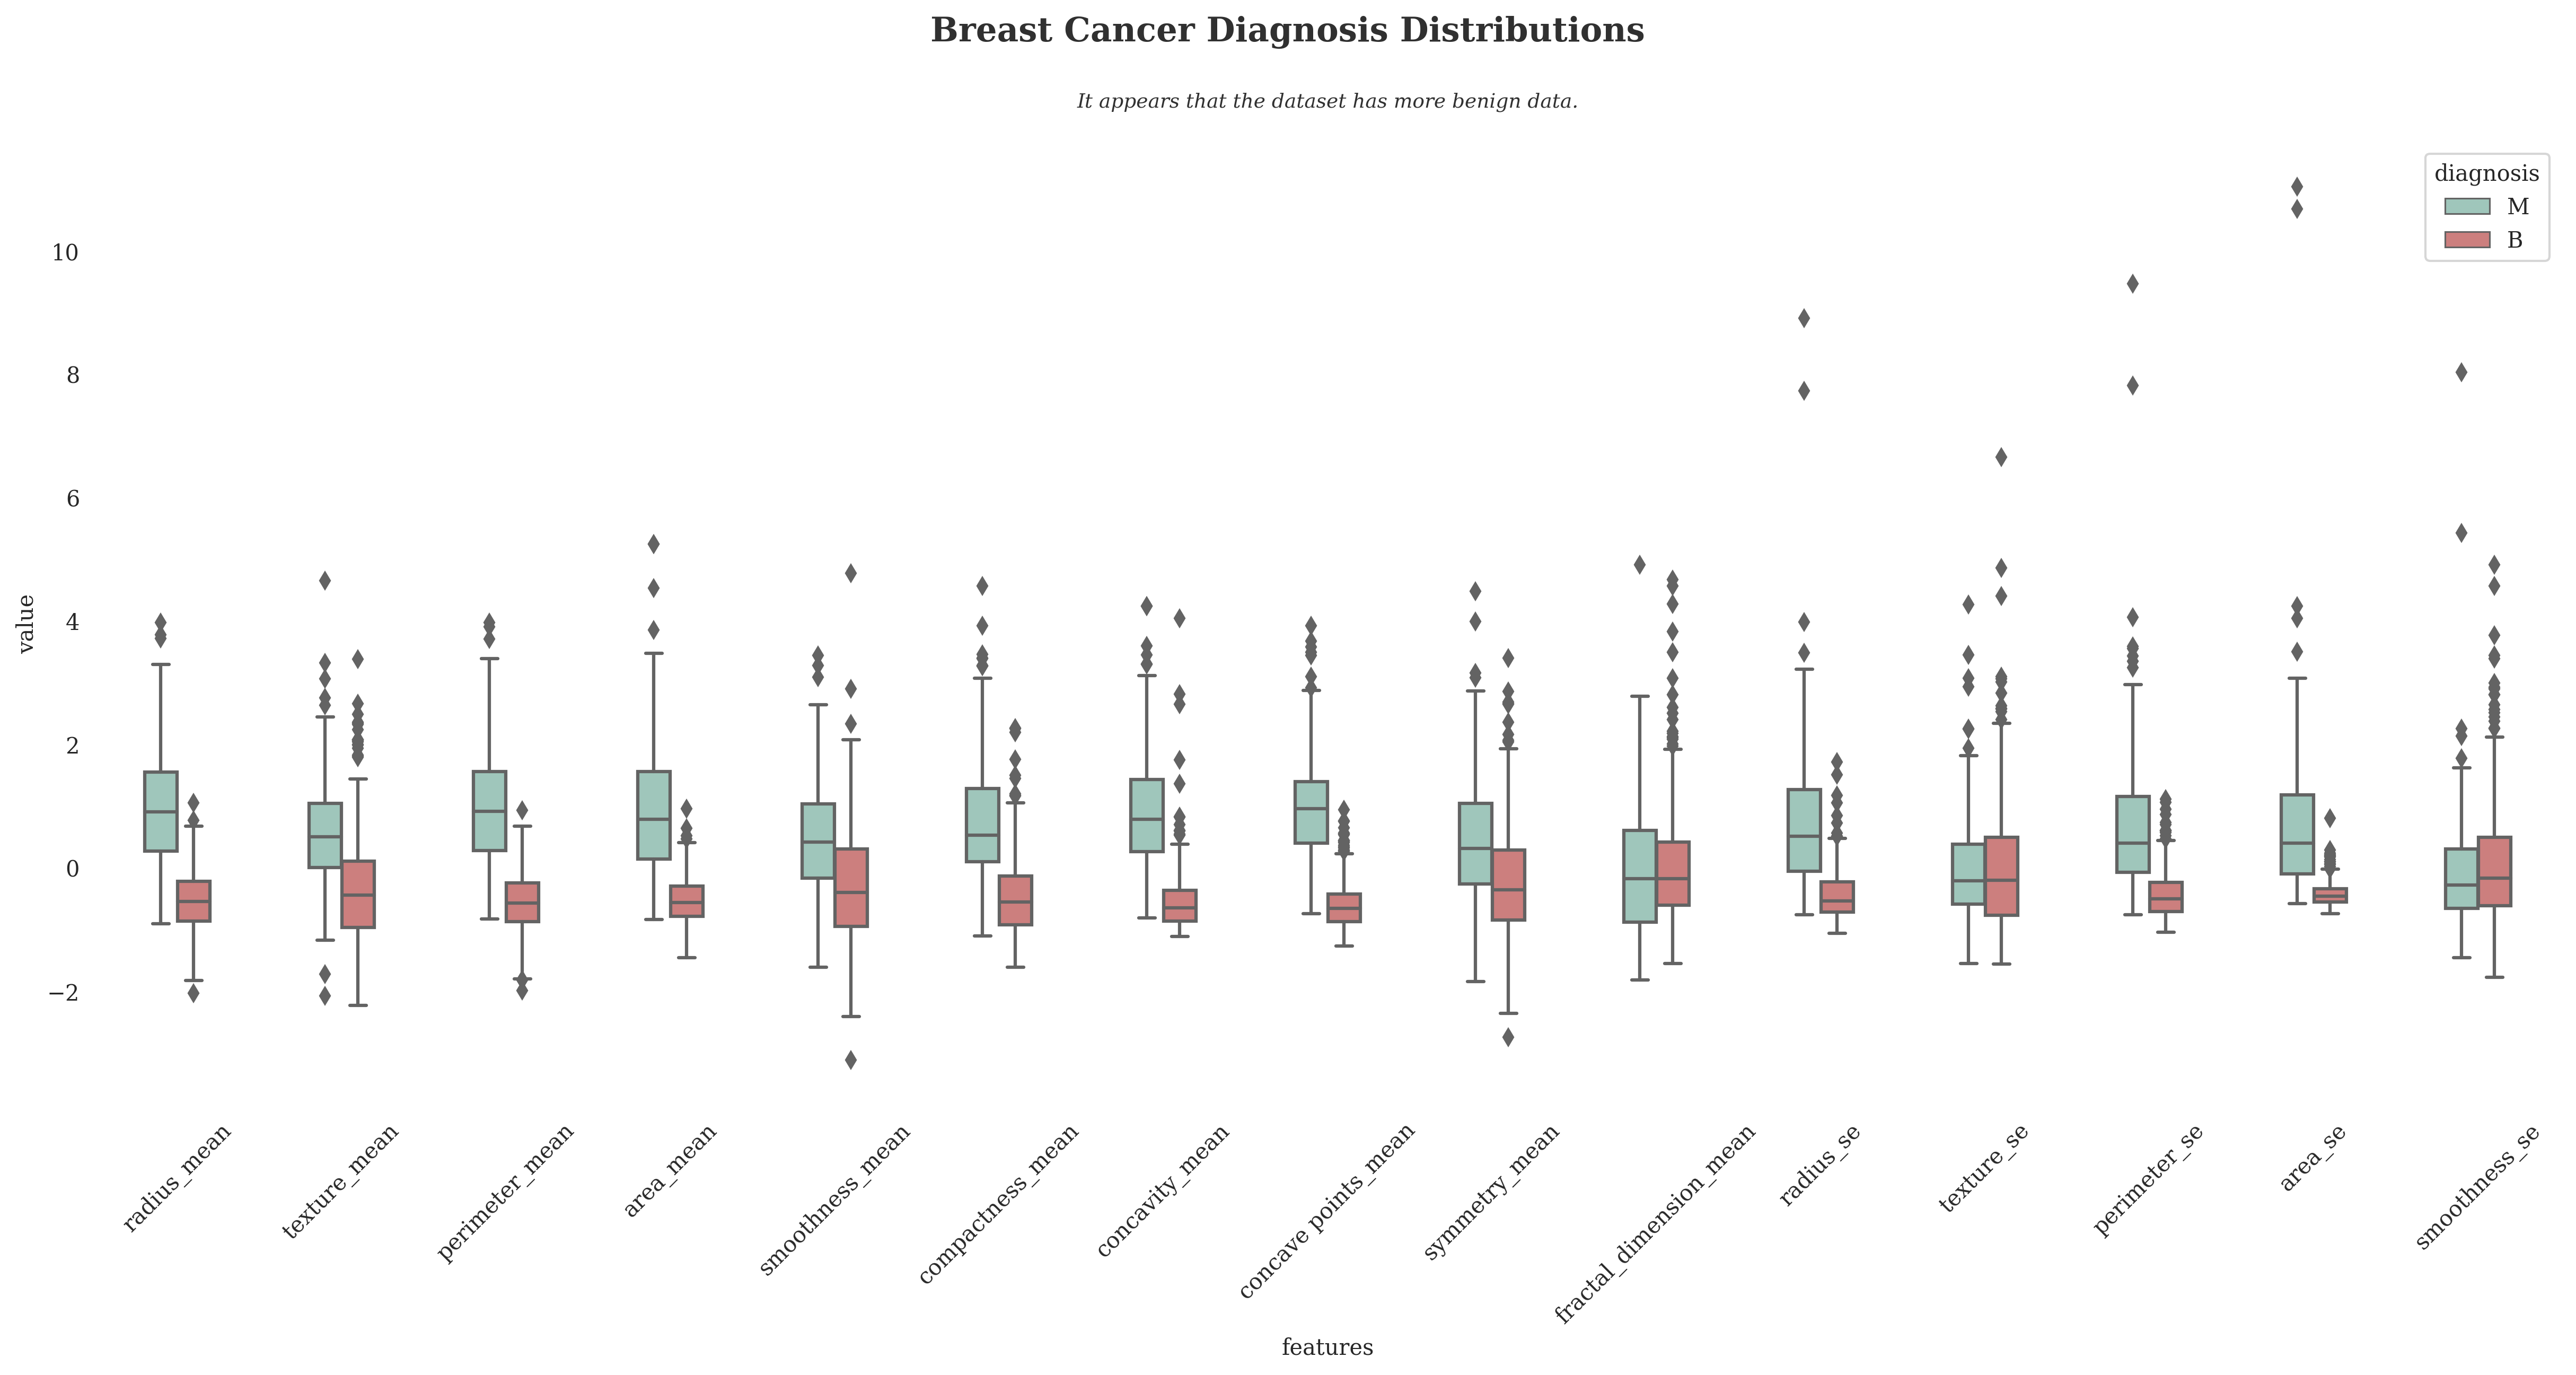

In [ ]:
# Standarization of dataset
from sklearn import preprocessing
import copy

df_S = df.copy()
df_S[df_S.columns[1:]] = preprocessing.scale(df[df.columns[1:]])
features = df_S['diagnosis']
data = df_S[df_S.columns[1:]]
boxplot1 = pd.concat([features,data.iloc[:,0:15]],axis=1)
boxplot1 = pd.melt(boxplot1,id_vars="diagnosis",var_name="features",value_name='value')

# Main figure
fig, ax = plt.subplots()
fig.set_size_inches(20, 8)
sns.boxplot(x="features", y="value", hue="diagnosis", data=boxplot1,palette=colors[1:3],width=0.4)
plt.xticks(rotation=45)

# Title and subtitle
plt.suptitle('Breast Cancer Diagnosis Distributions', fontweight='heavy', ha='center', fontsize=15, color=colors[0])
plt.title('It appears that the dataset has more benign data.\n',
          style='italic', fontsize=9, loc='center', ha='center',  color=colors[0])

plt.show()

[Text(0.5, 217.7777777777784, 'radius_mean')]

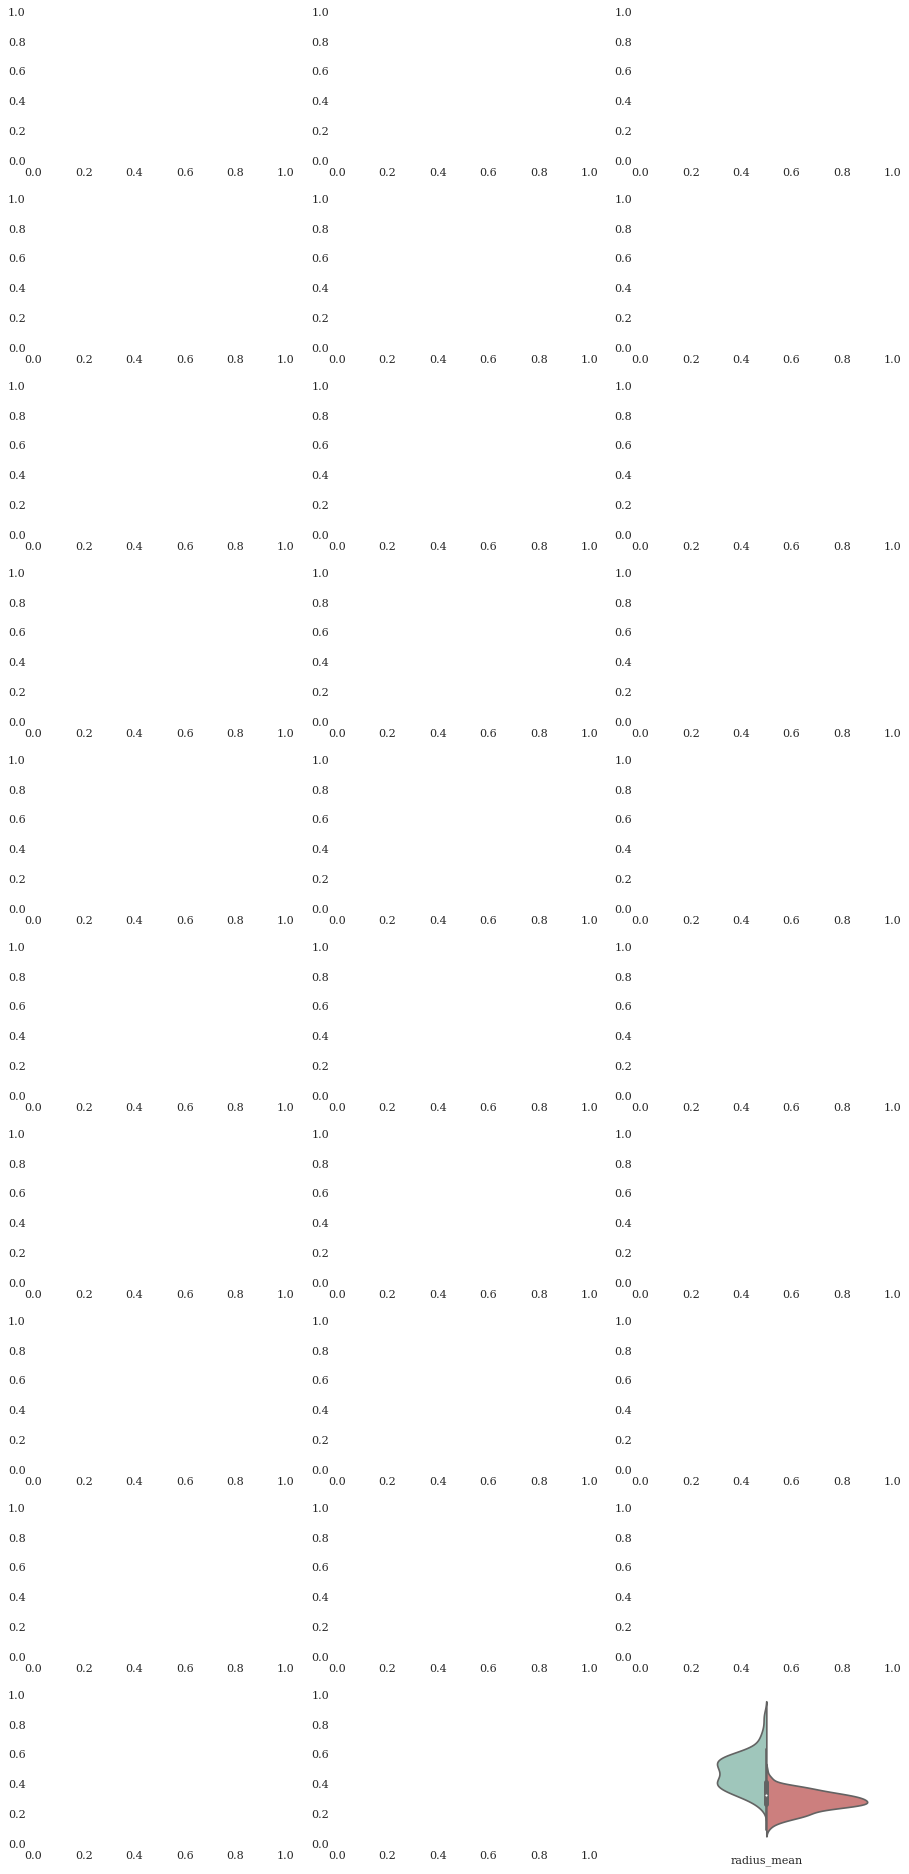

In [ ]:
fig,ax = plt.subplots(nrows = 10, ncols = 3, figsize = (12,24),dpi=80)
axes = ax.ravel()
plt.tight_layout(pad= 3,h_pad = 1.5, w_pad = 1.5)
df_S["all"] = ""
g1 = sns.violinplot(x= 'all', y= 'radius_mean', hue="diagnosis", data=df_S,palette=colors[1:3], split=True)
plt.legend([],[], frameon=False)
g1.set(xticklabels=[])
g1.set(yticklabels=[])
g1.set(ylabel=None)
g1.set(xlabel='radius_mean')

### Feature Engineering

### PCA

### Models

In [ ]:
# Logistic Modles


In [ ]:
# KNN


In [ ]:
# K-means


In [ ]:
# SVM


In [ ]:
# ANN


### Dataset 2: Web Scrape